# Step 1: Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (12,9)
plt.rcParams['font.size'] = 10

from sklearn.compose import make_column_transformer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score, classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras import Model, Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import mae
from tensorflow.keras.metrics import Mean
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Step 2: Loading Data

In [ ]:
import os
datapath = os.path.join("your_path", "")

In [ ]:
df = pd.read_csv("your_dataset.csv")

# Step 3: Preprocessing

In [4]:
from sklearn.preprocessing import LabelEncoder

def preprocess_data(train, label_encoders=None, fit_scaler=True, scaler=None):
    # selected_columns = [
    #     'amt', 'category', 'gender', 'state',
    #     'city_pop', 'lat', 'long',
    #     'merch_lat', 'merch_long'
    # ]
    # x = train[selected_columns].copy()

    y = train['is_fraud']
    x = train.drop(columns=['is_fraud'])

    # Encode categorical variables
    if label_encoders is None:
        label_encoders = {}
        for col in x.select_dtypes(include='object').columns:
            le = LabelEncoder()
            x[col] = le.fit_transform(x[col])
            label_encoders[col] = le
    else:
        for col in x.select_dtypes(include='object').columns:
            le = label_encoders[col]
            x[col] = le.transform(x[col])

    # Scale the features
    if fit_scaler:
        scaler = StandardScaler()
        x_scaled = scaler.fit_transform(x)
    else:
        x_scaled = scaler.transform(x)

    return x_scaled, label_encoders, scaler

In [5]:
# Prepare Data
x_all, label_encoders, scaler = preprocess_data(df)
y_all = df['is_fraud']

# For training (non-fraud only)
x_train = x_all[y_all == 0]

# For testing (all data)
x_test = x_all
y_test = y_all

# Step 4: Model Building - Autoencoder

In [6]:
CODE_DIM = 2
INPUT_SHAPE = x_train.shape[1]

input_layer = Input(shape=(INPUT_SHAPE,))
x = Dense(64, activation='relu')(input_layer)
x = Dense(16, activation='relu')(x)
code = Dense(CODE_DIM, activation='relu')(x)
x = Dense(16, activation='relu')(code)
x = Dense(64, activation='relu')(x)
output_layer = Dense(INPUT_SHAPE, activation='relu')(x)

autoencoder = Model(input_layer, output_layer, name='anomaly')

In [7]:
# Model callbacks
model_name = "anomaly.weights.h5"
checkpoint = ModelCheckpoint(model_name,
                            monitor="val_loss",
                            mode="min",
                            save_best_only = True,
                            save_weights_only=True,
                            verbose=1)
earlystopping = EarlyStopping(monitor='val_loss',
                              min_delta = 0,
                              patience = 5,
                              verbose = 1,
                              restore_best_weights=True)

callbacks = [checkpoint, earlystopping]

In [9]:
# Compilation
autoencoder.compile(loss='mae',
                    optimizer=Adam())

In [10]:
# Training
history = autoencoder.fit(x_train, x_train,
                          epochs=20, batch_size=64,
                          validation_data=(x_test, x_test),
                          callbacks=callbacks, shuffle=True)

Epoch 1/20
20107/20144 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6819
Epoch 1: val_loss improved from inf to 0.66656, saving model to anomaly.weights.h5
20144/20144 ━━━━━━━━━━━━━━━━━━━━ 75s 4ms/step - loss: 0.6819 - val_loss: 0.6666
Epoch 2/20
20112/20144 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6647
Epoch 2: val_loss improved from 0.66656 to 0.65738, saving model to anomaly.weights.h5
20144/20144 ━━━━━━━━━━━━━━━━━━━━ 60s 3ms/step - loss: 0.6647 - val_loss: 0.6574
Epoch 3/20
20105/20144 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.6560
Epoch 3: val_loss improved from 0.65738 to 0.65544, saving model to anomaly.weights.h5
20144/20144 ━━━━━━━━━━━━━━━━━━━━ 53s 3ms/step - loss: 0.6560 - val_loss: 0.6554
Epoch 4/20
20138/20144 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.6545
Epoch 4: val_loss improved from 0.65544 to 0.65468, saving model to anomaly.weights.h5
20144/20144 ━━━━━━━━━━━━━━━━━━━━ 53s 3ms/step - loss: 0.6545 - val_loss: 0.6547
Epoch 5/20
20125/20144 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/s

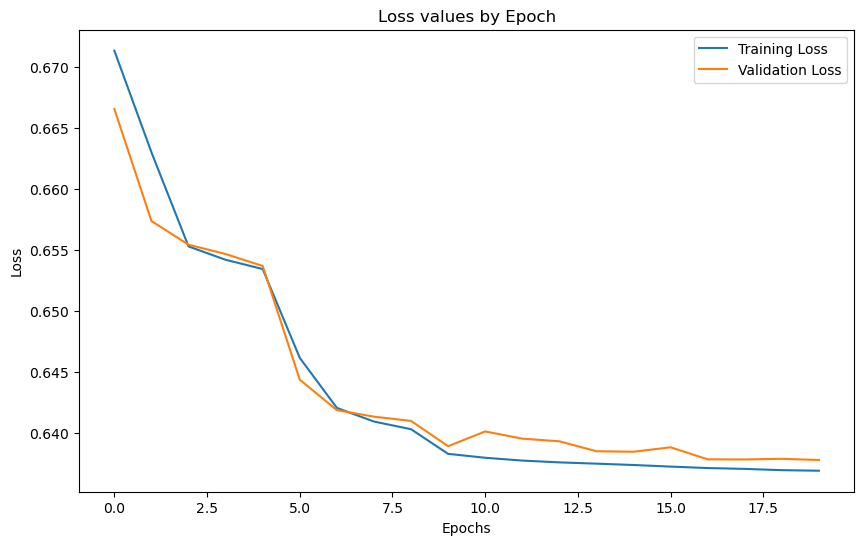

In [11]:
# Results
plt.figure(figsize=(10,6))
plt.plot(history.history['loss'], label="Training Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title("Loss values by Epoch")
plt.show()

# Step 5: Reconstruction

In [12]:
reconstructions = autoencoder.predict(x_test, verbose=0)
reconstruction_error = mae(reconstructions, x_test)

In [13]:
# Create Dataframe with Reconstruction Error and True Labels
recons_df = pd.DataFrame({
    'error': reconstruction_error,
    'y_true': y_test
}).reset_index(drop=True)
recons_df.head()

,error,y_true
0,0.531795,0
1,0.649815,0
2,0.773661,0
3,0.869148,0
4,0.545734,0


In [14]:
# Find the Ideal Threshold
def thresholdTuning(df, iterations):

    thresh_df = {
        'threshold': [],
        'accuracy': [],
        'precision': [],
        'recall': []
    }

    for i in range(iterations):
        thresh_value = df['error'].quantile(i/iterations)
        preds = df['error'] > thresh_value
        cr = classification_report(df['y_true'], preds, output_dict=True)
        acc = cr['accuracy']
        prec = cr['macro avg']['precision']
        rc = cr['macro avg']['recall']

        thresh_df['threshold'].append(thresh_value)
        thresh_df['accuracy'].append(acc)
        thresh_df['precision'].append(prec)
        thresh_df['recall'].append(rc)

        print(f"Threshold: {thresh_value:.4f}\tAccuracy: {acc:.3f}\t\tPrecision: {prec:.3f}\tRecall Score: {rc:.3f}")

    return pd.DataFrame(thresh_df)

thresh_df = thresholdTuning(recons_df, 10)

Threshold: 0.1615	Accuracy: 0.006		Precision: 0.503	Recall Score: 0.500
Threshold: 0.4599	Accuracy: 0.106		Precision: 0.503	Recall Score: 0.539
Threshold: 0.5096	Accuracy: 0.205		Precision: 0.503	Recall Score: 0.576
Threshold: 0.5471	Accuracy: 0.305		Precision: 0.503	Recall Score: 0.610
Threshold: 0.5808	Accuracy: 0.404		Precision: 0.503	Recall Score: 0.640
Threshold: 0.6140	Accuracy: 0.504		Precision: 0.504	Recall Score: 0.668
Threshold: 0.6497	Accuracy: 0.603		Precision: 0.504	Recall Score: 0.688
Threshold: 0.6919	Accuracy: 0.702		Precision: 0.505	Recall Score: 0.701
Threshold: 0.7484	Accuracy: 0.801		Precision: 0.507	Recall Score: 0.701
Threshold: 0.8407	Accuracy: 0.899		Precision: 0.511	Recall Score: 0.671


In [15]:
threshold = thresh_df[thresh_df['recall'] == thresh_df['recall'].max()]['threshold'].values[0]
print(f"Threshold with Maximum Recall: {threshold:.6f}")

Threshold with Maximum Recall: 0.748392


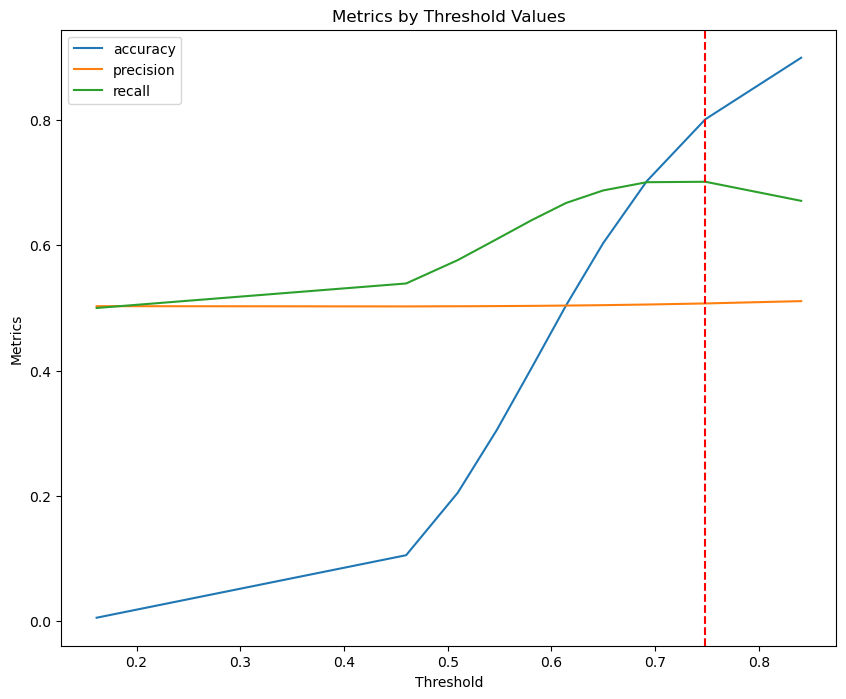

In [16]:
plt.figure(figsize=(10,8))
plt.plot(thresh_df['threshold'], thresh_df['accuracy'], label='accuracy')
plt.plot(thresh_df['threshold'], thresh_df['precision'], label='precision')
plt.plot(thresh_df['threshold'], thresh_df['recall'], label='recall')
plt.axvline(x=threshold, color='r', linestyle='dashed')
plt.xlabel('Threshold')
plt.ylabel('Metrics')
plt.title('Metrics by Threshold Values')
plt.legend()
plt.show()

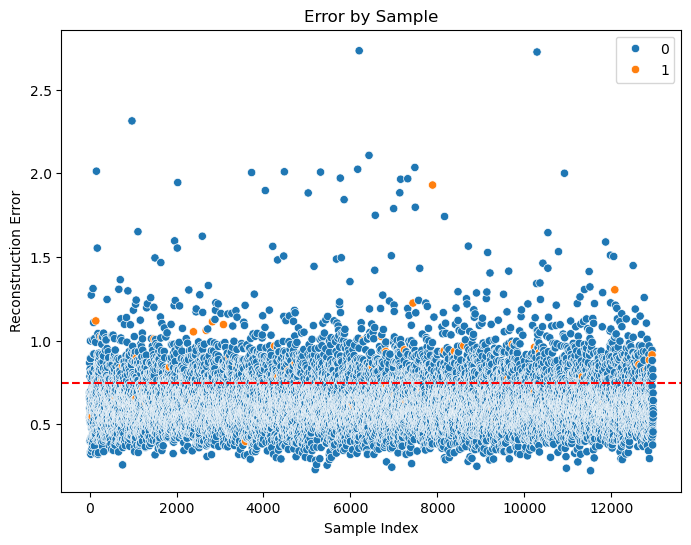

In [17]:
temp = recons_df.sample(frac=0.01, random_state=42).reset_index(drop=True)
plt.figure(figsize=(8,6))
sns.scatterplot(data=temp, x=temp.index, y='error', hue='y_true')
plt.axhline(y=threshold, color='r', linestyle='dashed')
plt.xlabel('Sample Index')
plt.ylabel('Reconstruction Error')
plt.title('Error by Sample')
plt.legend()
plt.show()

# Step 6: CLassification

In [18]:
recons_df['y_pred'] = recons_df['error'] > threshold
recons_df.head()

,error,y_true,y_pred
0,0.531795,0,False
1,0.649815,0,False
2,0.773661,0,True
3,0.869148,0,True
4,0.545734,0,False


In [19]:
print(classification_report(recons_df['y_true'],recons_df['y_pred']))

              precision    recall  f1-score   support

           0       1.00      0.80      0.89   1289169
           1       0.02      0.60      0.03      7506

    accuracy                           0.80   1296675
   macro avg       0.51      0.70      0.46   1296675
weighted avg       0.99      0.80      0.88   1296675



[[1034341  254828]
 [   2999    4507]]


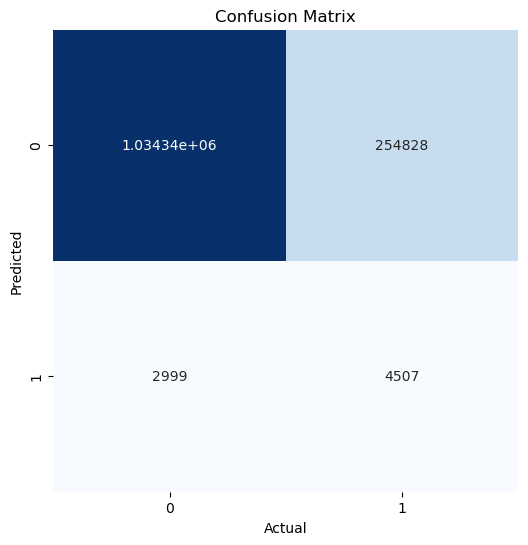

In [20]:
cm = confusion_matrix(recons_df['y_true'],recons_df['y_pred'])
print(cm)
plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, cmap='Blues', cbar=False, fmt='.6g')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

# Step 7: Results

In [21]:
from sklearn.metrics import f1_score, precision_score

print(f"Accuracy Score: {accuracy_score(recons_df['y_true'],recons_df['y_pred'])*100:.3f}%")
print(f"Recall Score: {recall_score(recons_df['y_true'],recons_df['y_pred'])*100:.3f}%")
print(f"F1 Score: {f1_score(recons_df['y_true'],recons_df['y_pred'])*100:.3f}%")
print(f"Precision Score: {precision_score(recons_df['y_true'],recons_df['y_pred'])*100:.3f}%")

Accuracy Score: 80.116%
Recall Score: 60.045%
F1 Score: 3.378%
Precision Score: 1.738%


In [22]:
# ROC AUC Score
from sklearn.metrics import roc_auc_score

roc_auc_score(recons_df['y_true'],recons_df['y_pred'])
print(f"ROC AUC Score: {roc_auc_score(recons_df['y_true'],recons_df['y_pred'])*100:.3f}%")

ROC AUC Score: 70.139%


In [23]:
# MSE Traning Data
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(x_train, autoencoder.predict(x_train))
print(f"MSE Traning Data: {mse:.3f}")

40287/40287 ━━━━━━━━━━━━━━━━━━━━ 41s 1ms/step
MSE Traning Data: 0.822


In [24]:
print("Final Training Loss:", history.history['loss'][-1])
print("Final Validation Loss:", history.history['val_loss'][-1])

Final Training Loss: 0.6369200944900513
Final Validation Loss: 0.6377987861633301
